In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pymargins import Margins

rng = np.random.default_rng(42)
n = 2000
df = pd.DataFrame({
    "x": rng.normal(50, 10, n),
    "female": rng.binomial(1, 0.52, n),
})
lp = -1.5 + 0.03 * df["x"] - 0.3 * df["female"]
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.glm("y ~ x + female", data=df,
              family=sm.families.Binomial()).fit()
m = Margins.log_scale(fit, at="overall")

In [2]:
x_bar = df["x"].mean()                       # or median, depending on theory
y_bar = m.predict().estimate.item()          # AAP on the response scale

# eyex: full elasticity at the mean
print(m.dydx("x").scaled(by=x_bar / y_bar).summary())

                    Margins Result (delta, level=0.95)                    
                       estimate  std err        z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------------------------
(x)*110.9958295306184    0.8661  11.3359  -0.0127  0.990    0.7089, 1.0580

n = 2000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
κ: 0.281
Delta-vs-sim disagreement: 9.998%


In [3]:
profile_x = 5.0
y_at = m.predict(atexog={"x": profile_x}).estimate.item()
print(m.dydx("x", atexog={"x": profile_x}).scaled(by=profile_x / y_at).summary())

/home/hunter/Workspace/pymargins/.venv/lib/python3.12/site-packages/pymargins/margins/_session.py:716: UserWarning: Delta-method curvature κ=1.467 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


                     Margins Result (simulation, level=0.95)                      
                             estimate  std err  statistic  P>|z|  [95% Conf. Int.]
----------------------------------------------------------------------------------
(x=5.0, x)*31.4306356608259    0.0937   8.1270    -2.3680  0.000    0.0689, 0.1873

n = 2000
WARNING — Fallback triggered: kappa=1.467>threshold=0.3
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
κ: 1.467


In [4]:
# Subgroup means for scaling
x_bar_0 = df.loc[df["female"] == 0, "x"].mean()
y_bar_0 = m.predict(atexog={"female": 0}).estimate.item()
x_bar_1 = df.loc[df["female"] == 1, "x"].mean()
y_bar_1 = m.predict(atexog={"female": 1}).estimate.item()

# Elasticity of x for female=0 and female=1
res_0 = m.dydx("x", atexog={"female": 0}).scaled(by=x_bar_0 / y_bar_0)
res_1 = m.dydx("x", atexog={"female": 1}).scaled(by=x_bar_1 / y_bar_1)

# Difference in elasticities with a proper SE
diff = res_1 - res_0
print(diff.summary())

                                            Margins Result (delta, level=0.95)                                            
                                                                        estimate  std err       z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------------------------------------------------------------------------
((female=1, x)*124.31135122094987) - ((female=0, x)*98.94062025641874)    1.2065   2.5430  0.0738  0.941  0.0083, 176.2506

n = 2000
Note: std err is on the inference scale; estimate and CI are on the reporting scale.
κ: 0.155


[Text(0, 0.5, 'Elasticity of x')]

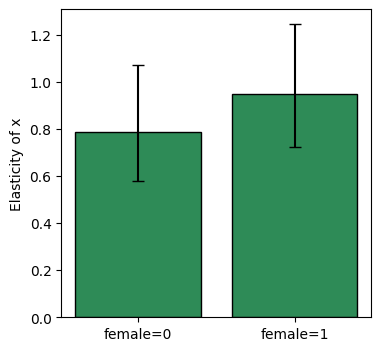

In [5]:
import matplotlib.pyplot as plt

df_0 = res_0.to_frame()
df_1 = res_1.to_frame()

labels = ["female=0", "female=1"]
estimates = [df_0["estimate"].iloc[0], df_1["estimate"].iloc[0]]
ci_lower = [df_0["ci_lower"].iloc[0], df_1["ci_lower"].iloc[0]]
ci_upper = [df_0["ci_upper"].iloc[0], df_1["ci_upper"].iloc[0]]

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(labels, estimates,
       yerr=[np.array(estimates) - np.array(ci_lower),
             np.array(ci_upper) - np.array(estimates)],
       capsize=4, color="seagreen", edgecolor="black")
ax.set(ylabel="Elasticity of x")